To run this, press "*Runtime*" and press "*Run all*" on a **free** Tesla T4 Google Colab instance!
<div class="align-center">
<a href="https://unsloth.ai/"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
<a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord button.png" width="145"></a>
<a href="https://unsloth.ai/docs/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a> Join Discord if you need help + ⭐ <i>Star us on <a href="https://github.com/unslothai/unsloth">Github</a> </i> ⭐
</div>

To install Unsloth on your local device, follow [our guide](https://unsloth.ai/docs/get-started/install). This notebook is licensed [LGPL-3.0](https://github.com/unslothai/notebooks?tab=LGPL-3.0-1-ov-file#readme).

You will learn how to do [data prep](#Data), how to [train](#Train), how to [run the model](#Inference), & how to save it

### News

Introducing **Unsloth Studio** - a new open source, no-code web UI to train and run LLMs. [Blog](https://unsloth.ai/docs/new/studio) • [Notebook](https://colab.research.google.com/github/unslothai/unsloth/blob/main/studio/Unsloth_Studio_Colab.ipynb)

<table><tr>
<td align="center"><a href="https://unsloth.ai/docs/new/studio"><img src="https://unsloth.ai/docs/~gitbook/image?url=https%3A%2F%2F3215535692-files.gitbook.io%2F~%2Ffiles%2Fv0%2Fb%2Fgitbook-x-prod.appspot.com%2Fo%2Fspaces%252FxhOjnexMCB3dmuQFQ2Zq%252Fuploads%252FxV1PO5DbF3ksB51nE2Tw%252Fmore%2520cropped%2520ui%2520for%2520homepage.png%3Falt%3Dmedia%26token%3Df75942c9-3d8d-4b59-8ba2-1a4a38de1b86&width=376&dpr=3&quality=100&sign=a663c397&sv=2" width="200" height="120" alt="Unsloth Studio Training UI"></a><br><sub><b>Train models</b> — no code needed</sub></td>
<td align="center"><a href="https://unsloth.ai/docs/new/studio"><img src="https://unsloth.ai/docs/~gitbook/image?url=https%3A%2F%2F3215535692-files.gitbook.io%2F~%2Ffiles%2Fv0%2Fb%2Fgitbook-x-prod.appspot.com%2Fo%2Fspaces%252FxhOjnexMCB3dmuQFQ2Zq%252Fuploads%252FRCnTAZ6Uh88DIlU3g0Ij%252Fmainpage%2520unsloth.png%3Falt%3Dmedia%26token%3D837c96b6-bd09-4e81-bc76-fa50421e9bfb&width=376&dpr=3&quality=100&sign=c1a39da1&sv=2" width="200" height="120" alt="Unsloth Studio Chat UI"></a><br><sub><b>Run GGUF models</b> on Mac, Windows & Linux</sub></td>
</tr></table>

Train MoEs - DeepSeek, GLM, Qwen and gpt-oss 12x faster with 35% less VRAM. [Blog](https://unsloth.ai/docs/new/faster-moe)

Ultra Long-Context Reinforcement Learning is here with 7x more context windows! [Blog](https://unsloth.ai/docs/new/grpo-long-context)

New in Reinforcement Learning: [FP8 RL](https://unsloth.ai/docs/new/fp8-reinforcement-learning) • [Vision RL](https://unsloth.ai/docs/new/vision-reinforcement-learning-vlm-rl) • [Standby](https://unsloth.ai/docs/basics/memory-efficient-rl) • [gpt-oss RL](https://unsloth.ai/docs/new/gpt-oss-reinforcement-learning)

Visit our docs for all our [model uploads](https://unsloth.ai/docs/get-started/unsloth-model-catalog) and [notebooks](https://unsloth.ai/docs/get-started/unsloth-notebooks).

### Installation

In [1]:
%%capture
import os, importlib.util
!pip install --upgrade -qqq uv
if importlib.util.find_spec("torch") is None or "COLAB_" in "".join(os.environ.keys()):
    try: import numpy, PIL; _numpy = f"numpy=={numpy.__version__}"; _pil = f"pillow=={PIL.__version__}"
    except: _numpy = "numpy"; _pil = "pillow"
    !uv pip install -qqq \
        "torch==2.8.0" "triton>=3.3.0" {_numpy} {_pil} torchvision bitsandbytes xformers==0.0.32.post2 \
        "unsloth_zoo[base] @ git+https://github.com/unslothai/unsloth-zoo" \
        "unsloth[base] @ git+https://github.com/unslothai/unsloth"
    !uv pip install -qqq --no-deps "torchcodec==0.7.0"
elif importlib.util.find_spec("unsloth") is None:
    !uv pip install -qqq unsloth
!uv pip install --upgrade --no-deps "tokenizers>=0.22.0,<=0.23.0" trl==0.22.2 unsloth unsloth_zoo
!uv pip install transformers==5.2.0
# causal_conv1d is supported only on torch==2.8.0. If you have newer torch versions, please wait 10 minutes!
!uv pip install --no-build-isolation flash-linear-attention causal_conv1d==1.6.0
import torch
if torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 8:
    !uv pip install --no-deps "apache-tvm-ffi==0.1.9" "tilelang==0.1.8"
else:
    os.environ["FLA_TILELANG"] = "0"
!uv pip install --no-deps --upgrade "torchao>=0.16.0"

### Unsloth

In [17]:
from unsloth import FastVisionModel
import torch

# Re-loading with 4bit for Tesla T4 stability
model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen3.5-0.8B",
    load_in_4bit = True,
    use_gradient_checkpointing = "unsloth",
)

==((====))==  Unsloth 2026.7.2: Fast Qwen3_5 patching. Transformers: 5.2.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for qwen3_5 won't work! Using float32.


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

We now add LoRA adapters for parameter efficient finetuning - this allows us to only efficiently train 1% of all parameters.

**[NEW]** We also support finetuning ONLY the vision part of the model, or ONLY the language part. Or you can select both! You can also select to finetune the attention or the MLP layers!

In [19]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True,
    finetune_language_layers   = True,
    finetune_attention_modules = True,
    finetune_mlp_modules       = True,
    r = 16,
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)

<a name="Data"></a>
### Data Prep
We'll be using a sampled dataset of handwritten maths formulas. The goal is to convert these images into a computer readable form - ie in LaTeX form, so we can render it. This can be very useful for complex formulas.

You can access the dataset [here](https://huggingface.co/datasets/unsloth/LaTeX_OCR). The full dataset is [here](https://huggingface.co/datasets/linxy/LaTeX_OCR).

In [3]:
import json
from PIL import Image
import os

# Load local JSONL dataset
def load_local_dataset(file_path):
    data = []
    with open(file_path, 'r') as f:
        for line in f:
            data.append(json.loads(line))
    return data

# Using your local training file
dataset_raw = load_local_dataset('/content/okf_training_pairs.jsonl')
print(f'Loaded {len(dataset_raw)} samples.')

Loaded 696 samples.


Let's take an overview look at the dataset. We shall see what the 3rd image is, and what caption it had.

In [ ]:
dataset

Dataset({
    features: ['image', 'text'],
    num_rows: 68686
})

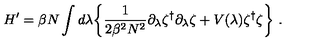

In [ ]:
dataset[2]["image"]

In [ ]:
dataset[2]["text"]

'H ^ { \\prime } = \\beta N \\int d \\lambda \\biggl \\{ \\frac { 1 } { 2 \\beta ^ { 2 } N ^ { 2 } } \\partial _ { \\lambda } \\zeta ^ { \\dagger } \\partial _ { \\lambda } \\zeta + V ( \\lambda ) \\zeta ^ { \\dagger } \\zeta \\biggr \\} \\ .'

We can also render the LaTeX in the browser directly!

In [ ]:
from IPython.display import display, Math, Latex

latex = dataset[2]["text"]
display(Math(latex))

<IPython.core.display.Math object>

To format the dataset, all vision finetuning tasks should be formatted as follows:

```python
[
{ "role": "user",
  "content": [{"type": "text",  "text": Q}, {"type": "image", "image": image} ]
},
{ "role": "assistant",
  "content": [{"type": "text",  "text": A} ]
},
]
```

In [7]:
instruction_prompt = "Extract OKF entities from the text."

def convert_to_conversation(sample):
    target_text = sample.get('output', '')
    user_text = sample.get('instruction', instruction_prompt)

    # Check for image in sample, otherwise use a placeholder white image
    if 'image' in sample:
        img = Image.open(sample['image']) if isinstance(sample['image'], str) else sample['image']
    else:
        img = Image.new('RGB', (224, 224), color = (255, 255, 255))

    conversation = [
        { "role": "user",
          "content" : [
            {"type" : "text",  "text"  : user_text},
            {"type" : "image", "image" : img} ]
        },
        { "role" : "assistant",
          "content" : [
            {"type" : "text",  "text"  : target_text} ]
        },
    ]
    return { "messages" : conversation }

Let's convert the dataset into the "correct" format for finetuning:

In [8]:
converted_dataset = [convert_to_conversation(sample) for sample in dataset_raw]
print(f"Successfully converted {len(converted_dataset)} samples.")

Successfully converted 696 samples.


In [23]:
import json

# Loading the new test dataset
test_data_path = '/content/okf_test_pairs.jsonl'
new_dataset_raw = []
with open(test_data_path, 'r') as f:
    for line in f:
        new_dataset_raw.append(json.loads(line))

print(f'Loaded {len(new_dataset_raw)} new test samples.')

# Convert to conversation format
new_converted_dataset = [convert_to_conversation(sample) for sample in new_dataset_raw]
print(f'Successfully converted {len(new_converted_dataset)} new samples.')

Loaded 92 new test samples.
Successfully converted 92 new samples.


In [24]:
from transformers import TextStreamer

# Set model to inference mode
FastVisionModel.for_inference(model)

# Test on the first few samples of the new test dataset
for i in range(3):
    sample = new_converted_dataset[i]['messages']
    user_message = sample[0]

    # Extract image and text from the user message
    test_image = next(item['image'] for item in user_message['content'] if item['type'] == 'image')
    test_prompt = next(item['text'] for item in user_message['content'] if item['type'] == 'text')

    print(f'\n--- Test Sample {i+1} ---')
    print(f'Prompt: {test_prompt}')

    inputs = tokenizer(
        test_image,
        tokenizer.apply_chat_template([user_message], add_generation_prompt = True),
        add_special_tokens = False,
        return_tensors = "pt",
    ).to("cuda")

    text_streamer = TextStreamer(tokenizer, skip_prompt = True)
    print('Response: ', end='')
    _ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 256, use_cache = True, temperature = 1.5, min_p = 0.1)
    print('\n' + '='*30)


--- Test Sample 1 ---
Prompt: You are an OKF extraction engine for the Archipelago knowledge graph.
From the TEXT below, extract 1-5 teachable CONCEPTS as a JSON array.

Each object MUST have exactly these keys:
concept_name, concept_type, difficulty, summary, prerequisites, unlocks, related_to, tags

Rules:
- concept_name: ≤ 5 words, a reusable noun phrase, Title Case.
- Only concepts actually explained in the text. No authors, citations, section titles.
- prerequisites = what a learner needs FIRST; unlocks = what this ENABLES next.
- A concept must NEVER appear in its own prerequisites or unlocks.
- Keep names stable across documents so the same concept merges into one node.
- If the text has no real teachable concept, return [].
- Output ONLY the JSON array. No prose, no markdown fences.

TEXT:
Language model pre-training has been shown to be effective for improving many natural language processing tasks (Dai and Le, 2015; Peters et al., 2018a; Radford et al., 2018; Howard and Rude

We look at how the conversations are structured for the first example:

In [ ]:
converted_dataset[0]

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': 'Write the LaTeX representation for this image.'},
    {'type': 'image',
     'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=160x40>}]},
  {'role': 'assistant',
   'content': [{'type': 'text',
     'text': '{ \\frac { N } { M } } \\in { \\bf Z } , { \\frac { M } { P } } \\in { \\bf Z } , { \\frac { P } { Q } } \\in { \\bf Z }'}]}]}

Let's first see before we do any finetuning what the model outputs for the first example!

In [ ]:
FastVisionModel.for_inference(model) # Enable for inference!

image = dataset[2]["image"]
instruction = "Write the LaTeX representation for this image."

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

 $$H ^ { \prime } = \beta N \int d \lambda \left\{ \frac { 1 } { 2 \beta ^ { 2 } N ^ { 2 } } \partial _ { \lambda } \zeta ^ { \dagger } \partial _ { \lambda } \zeta + V ( \lambda ) \zeta ^ { \dagger } \zeta \right\} .$$<|im_end|>
<|endoftext|>


<a name="Train"></a>
### Train the model
Now let's train our model. We do 60 steps to speed things up, but you can set `num_train_epochs=1` for a full run, and turn off `max_steps=None`. We also support `DPOTrainer` and `GRPOTrainer` for reinforcement learning!

We use our new `UnslothVisionDataCollator` which will help in our vision finetuning setup.

In [ ]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig
import torch

FastVisionModel.for_training(model)

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer),
    train_dataset = converted_dataset,
    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_ratio = 0.1,
        max_steps = 1500,
        learning_rate = 2e-4,
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
        logging_steps = 50,
        optim = "adamw_8bit",
        weight_decay = 0.05,
        lr_scheduler_type = "cosine",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 2048,
    ),
)

trainer_stats = trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Model does not have a default image size - using 512
Unsloth: Switching to float32 training since model cannot work with float16


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 696 | Num Epochs = 18 | Total steps = 1,500
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 13,181,952 of 866,167,872 (1.52% trained)


Step,Training Loss
50,0.766680
100,0.694272
150,0.596139
200,0.532125
250,0.457740
300,0.405415


Step,Training Loss
50,0.766680
100,0.694272
150,0.596139
200,0.532125
250,0.457740
300,0.405415
350,0.348817


In [ ]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.563 GB.
1.947 GB of memory reserved.


In [10]:
print("Training process initiated and stats recorded.")

Training process initiated and stats recorded.


In [ ]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

540.6141 seconds used for training.
9.01 minutes used for training.
Peak reserved memory = 2.441 GB.
Peak reserved memory for training = 0.494 GB.
Peak reserved memory % of max memory = 16.762 %.
Peak reserved memory for training % of max memory = 3.392 %.


<a name="Inference"></a>
### Inference
Let's run the model! You can change the instruction and input - leave the output blank!

We use `min_p = 0.1` and `temperature = 1.5`. Read this [Tweet](https://x.com/menhguin/status/1826132708508213629) for more information on why.

In [ ]:
FastVisionModel.for_inference(model) # Enable for inference!

image = dataset[2]["image"]
instruction = "Write the LaTeX representation for this image."

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

H ^ { \prime } = \beta N \int d \lambda \bigg \{ \frac { 1 } { 2 \beta ^ { 2 } N ^ { 2 } } \partial _ { \lambda } \zeta ^ { \dagger } \partial _ { \lambda } \zeta + V ( \lambda ) \zeta ^ { \dagger } \zeta \bigg \} \ .<|im_end|>


<a name="Save"></a>
### Saving, loading finetuned models
To save the final model as LoRA adapters, either use Hugging Face's `push_to_hub` for an online save or `save_pretrained` for a local save.

**[NOTE]** This ONLY saves the LoRA adapters, and not the full model. To save to 16bit or GGUF, scroll down!

In [ ]:
model.save_pretrained("qwen_lora")  # Local saving
tokenizer.save_pretrained("qwen_lora")
# model.push_to_hub("your_name/qwen_lora", token = "YOUR_HF_TOKEN") # Online saving
# tokenizer.push_to_hub("your_name/qwen_lora", token = "YOUR_HF_TOKEN") # Online saving

['qwen_lora/processor_config.json']

Now if you want to load the LoRA adapters we just saved for inference, set `False` to `True`:

In [ ]:
if False:
    from unsloth import FastVisionModel
    model, tokenizer = FastVisionModel.from_pretrained(
        model_name = "qwen_lora", # YOUR MODEL YOU USED FOR TRAINING
        load_in_4bit = True, # Set to False for 16bit LoRA
    )
    FastVisionModel.for_inference(model) # Enable for inference!

image = dataset[0]["image"]
instruction = "Write the LaTeX representation for this image."

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

\frac { N } { M } \in { \bf Z } , \frac { M } { P } \in { \bf Z } , \frac { P } { Q } \in { \bf Z }<|im_end|>


### Saving to float16 for VLLM

We also support saving to `float16` directly. Select `merged_16bit` for float16. Use `push_to_hub_merged` to upload to your Hugging Face account! You can go to https://huggingface.co/settings/tokens for your personal tokens. See [our docs](https://unsloth.ai/docs/basics/inference-and-deployment) for more deployment options.

In [ ]:
# Select ONLY 1 to save! (Both not needed!)

# Save locally to 16bit
if False: model.save_pretrained_merged("unsloth_finetune", tokenizer,)

# To export and save to your Hugging Face account
if False: model.push_to_hub_merged("YOUR_USERNAME/unsloth_finetune", tokenizer, token = "YOUR_HF_TOKEN")

### GGUF / llama.cpp Conversion
To save to `GGUF` / `llama.cpp`, we support it natively now! We clone `llama.cpp` and we default save it to `q8_0`. We allow all methods like `q4_k_m`. Use `save_pretrained_gguf` for local saving and `push_to_hub_gguf` for uploading to HF.

Some supported quant methods (full list on our [docs page](https://unsloth.ai/docs/basics/inference-and-deployment/saving-to-gguf)):
* `q8_0` - Fast conversion. High resource use, but generally acceptable.
* `q4_k_m` - Recommended. Uses Q6_K for half of the attention.wv and feed_forward.w2 tensors, else Q4_K.
* `q5_k_m` - Recommended. Uses Q6_K for half of the attention.wv and feed_forward.w2 tensors, else Q5_K.

[**NEW**] To finetune and auto export to Ollama, try our [Ollama notebook](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3_(8B)-Ollama.ipynb)

In [ ]:
# Save to 8bit Q8_0
if False: model.save_pretrained_gguf("qwen_finetune", tokenizer,)
# Remember to go to https://huggingface.co/settings/tokens for a token!
# And change hf to your username!
if False: model.push_to_hub_gguf("HF_USERNAME/qwen_finetune", tokenizer, token = "YOUR_HF_TOKEN")

# Save to 16bit GGUF
if False: model.save_pretrained_gguf("qwen_finetune", tokenizer, quantization_method = "f16")
if False: model.push_to_hub_gguf("HF_USERNAME/qwen_finetune", tokenizer, quantization_method = "f16", token = "YOUR_HF_TOKEN")

# Save to q4_k_m GGUF
if False: model.save_pretrained_gguf("qwen_finetune", tokenizer, quantization_method = "q4_k_m")
if False: model.push_to_hub_gguf("HF_USERNAME/qwen_finetune", tokenizer, quantization_method = "q4_k_m", token = "YOUR_HF_TOKEN")

# Save to multiple GGUF options - much faster if you want multiple!
if False:
    model.push_to_hub_gguf(
        "HF_USERNAME/qwen_finetune", # Change hf to your username!
        tokenizer,
        quantization_method = ["q4_k_m", "q8_0", "q5_k_m",],
        token = "YOUR_HF_TOKEN",
    )

And we're done! If you have any questions on Unsloth, we have a [Discord](https://discord.gg/unsloth) channel! If you find any bugs or want to keep updated with the latest LLM stuff, or need help, join projects etc, feel free to join our Discord!

Some other resources:
1. Looking to use Unsloth locally? Read our [Installation Guide](https://unsloth.ai/docs/get-started/install) for details on installing Unsloth on Windows, Docker, AMD, Intel GPUs.
2. Learn how to do Reinforcement Learning with our [RL Guide and notebooks](https://unsloth.ai/docs/get-started/reinforcement-learning-rl-guide).
3. Read our guides and notebooks for [Text-to-speech (TTS)](https://unsloth.ai/docs/basics/text-to-speech-tts-fine-tuning) and [vision](https://unsloth.ai/docs/basics/vision-fine-tuning) model support.
4. Explore our [LLM Tutorials Directory](https://unsloth.ai/docs/models/tutorials-how-to-fine-tune-and-run-llms) to find dedicated guides for each model.
5. Need help with Inference? Read our [Inference & Deployment page](https://unsloth.ai/docs/basics/inference-and-deployment) for details on using vLLM, llama.cpp, Ollama etc.

<div class="align-center">
  <a href="https://unsloth.ai"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
  <a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord.png" width="145"></a>
  <a href="https://unsloth.ai/docs/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a>

  Join Discord if you need help + ⭐️ <i>Star us on <a href="https://github.com/unslothai/unsloth">Github</a> </i> ⭐️

  <b>This notebook and all Unsloth notebooks are licensed [LGPL-3.0](https://github.com/unslothai/notebooks?tab=LGPL-3.0-1-ov-file#readme)</b>
</div>